In [3]:
import jax.numpy as jnp
import sys
sys.path.append("..")

from validation.cases import DICKINS_CASE
from src.simulation import boundary as boundary_mod
from src.simulation import dynamic_ray_tracing as dyn_mod
from src.simulation import sound_speed as ssp_mod

dyn_mod.configure_acoustic_operators(
    sound_speed_operators=ssp_mod.DEFAULT_OPERATORS,
    boundary_operators=boundary_mod.DEFAULT_BOUNDARY_OPERATORS,
    reflection_model={
        "source_type": "point",
        "top_boundary_condition": DICKINS_CASE.top_boundary_condition,
        "bottom_boundary_condition": DICKINS_CASE.bottom_boundary_condition,
        "kill_backward_rays": DICKINS_CASE.kill_backward_rays,
        "bottom_alpha_r_mps": DICKINS_CASE.bottom_alpha_r_mps,
        "bottom_alpha_i_user": DICKINS_CASE.bottom_alpha_i_user,
        "bottom_beta_r_mps": DICKINS_CASE.bottom_beta_r_mps,
        "bottom_beta_i_user": DICKINS_CASE.bottom_beta_i_user,
        "bottom_density_gcc": DICKINS_CASE.bottom_density_gcc,
        "attenuation_units": DICKINS_CASE.attenuation_units,
    },
)

rr_grid = jnp.asarray(DICKINS_CASE.rr_grid)
rz_grid = jnp.asarray(DICKINS_CASE.rz_grid)

result = dyn_mod.solve_transmission_loss(
    freq=DICKINS_CASE.frequency_hz,
    r_s=DICKINS_CASE.source_range_m,
    z_s=DICKINS_CASE.source_depth_m,
    theta_min=jnp.deg2rad(DICKINS_CASE.theta_min_deg),
    theta_max=jnp.deg2rad(DICKINS_CASE.theta_max_deg),
    n_beams=DICKINS_CASE.n_beams,
    rr_grid=rr_grid, 
    rz_grid=rz_grid,
    ds=DICKINS_CASE.ds_m,
    beam_type="geometric",
    run_mode="coherent",
    accumulation_model=DICKINS_CASE.beam_influence_model,
)

print(result["tl_db"].shape)


(601, 1001)


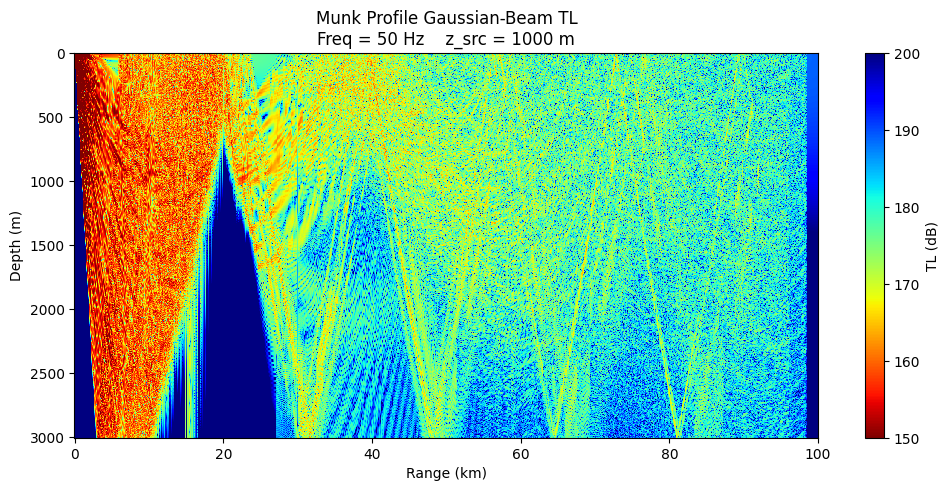

In [4]:
import matplotlib.pyplot as plt
from src.plot import plot_tl_field

fig, ax = plt.subplots(figsize=(12, 5))
plot_tl_field(
    rr_grid_m=rr_grid,
    rz_grid_m=rz_grid,
    tl_db=result["tl_db"],
    ax=ax,
    title="Munk Profile Gaussian-Beam TL",
    freq_hz=50.0,
    source_depth_m=1000.0,
)
plt.show()